In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
using SSMCMain.ModifiedMiCRM, SSMCMain.ModifiedMiCRM.MinimalModelV2
includet("../../../scripts/single_influx.jl")

In [3]:
using ProgressMeter
using ColorSchemes
using UnPack

In [4]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

In [5]:
methods(make_mmicrm_problem)

# 1 method for generic function "make_mmicrm_problem" from SSMCMain.ModifiedMiCRM:
 [1] make_mmicrm_problem(p::AbstractMMiCRMParams, u0, T; usejac, t0, kwargs...)
     @ ~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/src/SSMCMain/src/ModifiedMiCRM/ModifiedMiCRM.jl:139

In [21]:
mmp = MMParams(;
    K=17.,
    m=1.,
    c=1.,
    l=1.,
)
T = 1e8
tol = 1e-8

ode_ps = mmp_to_mmicrm(mmp;
    static=false,
)
ode_p = make_mmicrm_problem(ode_ps, [1., 0., 0.], T)
ode_s = solve(ode_p, QNDF();
    abstol=tol,
    reltol=tol,
)
@show mmicrmmaxresid(ode_s) ode_s.u[end];

mmicrmmaxresid(ode_s) = 1.7763568394002505e-15
ode_s.u[end] = [14.933034373659254, 1.0669656263407472, 1.0]


In [22]:
DN = 1e-6
DR = 1.

L = 10
sN = 2000

u0 = expand_u0_to_size((sN,), ode_s.u[end])
u0 = perturb_u0_uniform(1, 2, u0, 1e-3)

dx = L / sN

pde_ps = BSMMiCRMParams(ode_ps, [DN, 1., DR], CartesianSpace{1, Tuple{Periodic}}([dx]), nthreads())
pde_p = make_smmicrm_problem(pde_ps, u0, T);
@time pde_s = solve(pde_p, QNDF();
    callback=make_timer_callback(10),
    abstol=tol,
    reltol=tol,
);
@show smmicrmmaxresid(pde_s);

  4.608406 seconds (3.10 M allocations: 1.983 GiB, 10.48% gc time, 0.23% compilation time)
smmicrmmaxresid(pde_s) = 3.880849419601873e-9


In [23]:
xx = hcat((map(pde_s.u) do x x[1,:] end)...);

In [24]:
size(xx)

(2000, 2684)

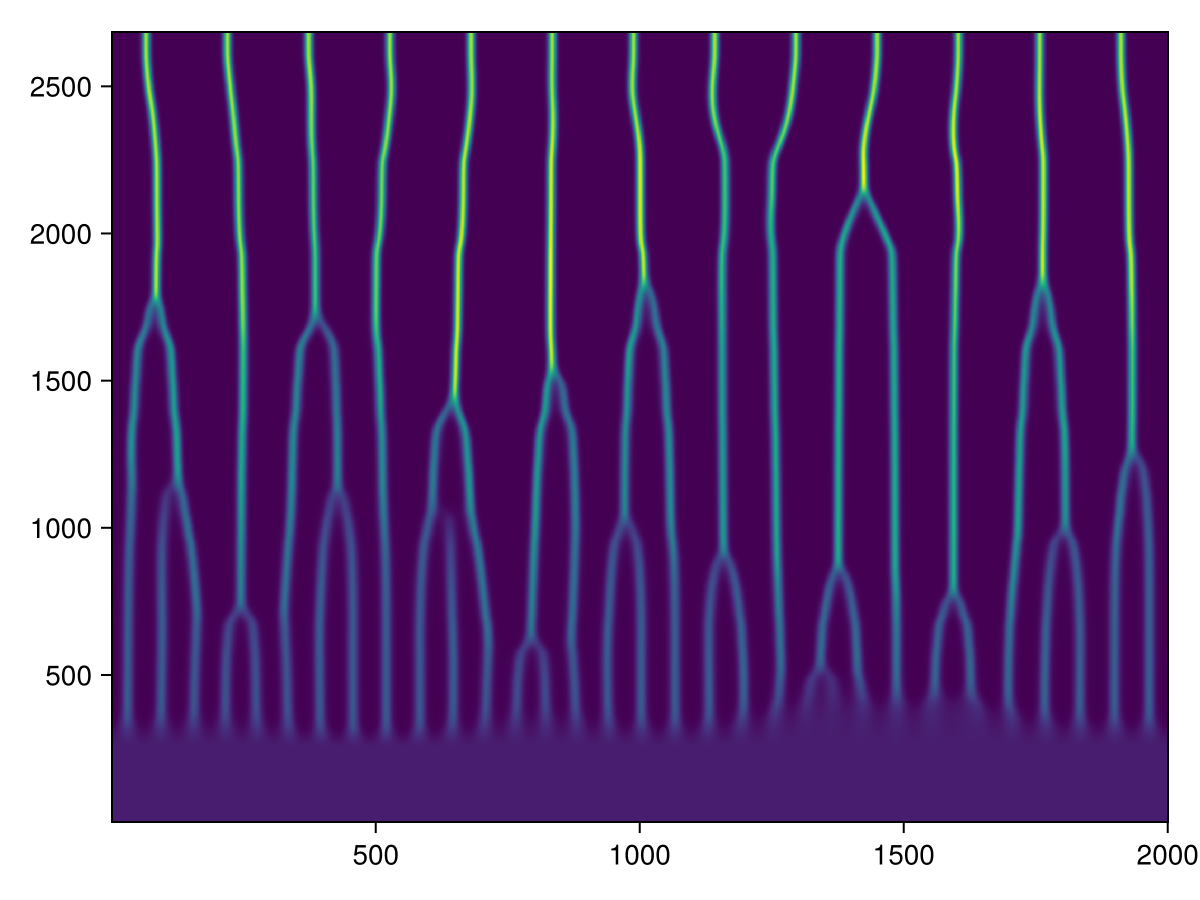

In [25]:
fap = heatmap(xx)
# Makie.save("../../../figures2/fig3/mm_coarsening_demo.png", fap.figure)
fap